In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!pip install kaggle

In [3]:
!kaggle datasets download -d nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone

Dataset URL: https://www.kaggle.com/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone
License(s): copyright-authors
 99% 1.51G/1.52G [00:10<00:00, 79.3MB/s]
100% 1.52G/1.52G [00:10<00:00, 161MB/s] 


In [4]:
!unzip ct-kidney-dataset-normal-cyst-tumor-and-stone.zip

Streaming output truncated to the last 5000 lines.
  inflating: CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4363).jpg  
  inflating: CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4364).jpg  
  inflating: CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4365).jpg  
  inflating: CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4366).jpg  
  inflating: CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4367).jpg  
  inflating: CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4368).jpg  
  inflating: CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (4369).jpg  
  inflating: CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-N

In [5]:
!ls

ct-kidney-dataset-normal-cyst-tumor-and-stone.zip  kaggle.json	   sample_data
CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone	   kidneyData.csv


#  Import libraries

In [6]:
import os
import numpy as np
import pandas as pd
import random
import warnings

warnings.filterwarnings('ignore')

# Deep Learning Libraries (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras import Sequential, Model, regularizers
from tensorflow.keras.layers import (
    Dense, BatchNormalization, Conv2D, MaxPooling2D, Flatten, Dropout,
    GlobalAveragePooling2D, Activation, Add, GaussianNoise, Reshape,
    SpatialDropout2D, LeakyReLU, ReLU, Lambda, Input
)
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy, AUC, Precision, Recall
from tensorflow.keras.applications import ResNet50V2, MobileNetV2
from tensorflow.keras.callbacks import (
    LearningRateScheduler, ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model, to_categorical

# Data Analysis and Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import shuffle, class_weight
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.manifold import TSNE
import cv2

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)




# split data

In [7]:
base_dir = r"CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

In [8]:
classes = ['Cyst', 'Tumor', 'Stone', 'Normal']

In [9]:
data = []
valid_extensions = ('.jpg')  # Supported file extensions

for label in classes:
    folder_path = os.path.join(base_dir, label)

    # Check if the folder exists before attempting to access it
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if file.lower().endswith(valid_extensions):  # Support for different extensions
            file_path = os.path.join(folder_path, file)
            data.append((file_path, label))



In [10]:
df = pd.DataFrame(data, columns=['file_path', 'label'])


In [11]:
df.head()

,file_path,label
0,CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...,Cyst
1,CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...,Cyst
2,CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...,Cyst
3,CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...,Cyst
4,CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...,Cyst


In [12]:
df.shape

(12446, 2)

In [13]:
df['label'].value_counts()

,count
label,
Normal,5077
Cyst,3709
Tumor,2283
Stone,1377


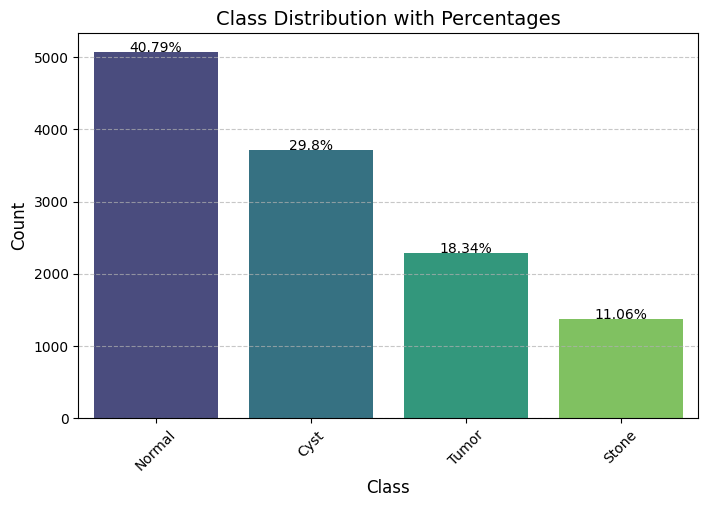

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


value_counts = df['label'].value_counts().reset_index()
value_counts.columns = ['label', 'count']
value_counts['percentage'] = (value_counts['count'] / value_counts['count'].sum() * 100).round(2)
value_counts = value_counts.sort_values(by="count", ascending=False)

plt.figure(figsize=(8, 5))

ax = sns.barplot(data=value_counts, x='label', y='count', palette="viridis")

for i, row in value_counts.iterrows():
    ax.text(i, row['count'] + 2, f"{row['percentage']}%", ha='center', fontsize=10, color='black')

plt.title("Class Distribution with Percentages", fontsize=14)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



# sample for images

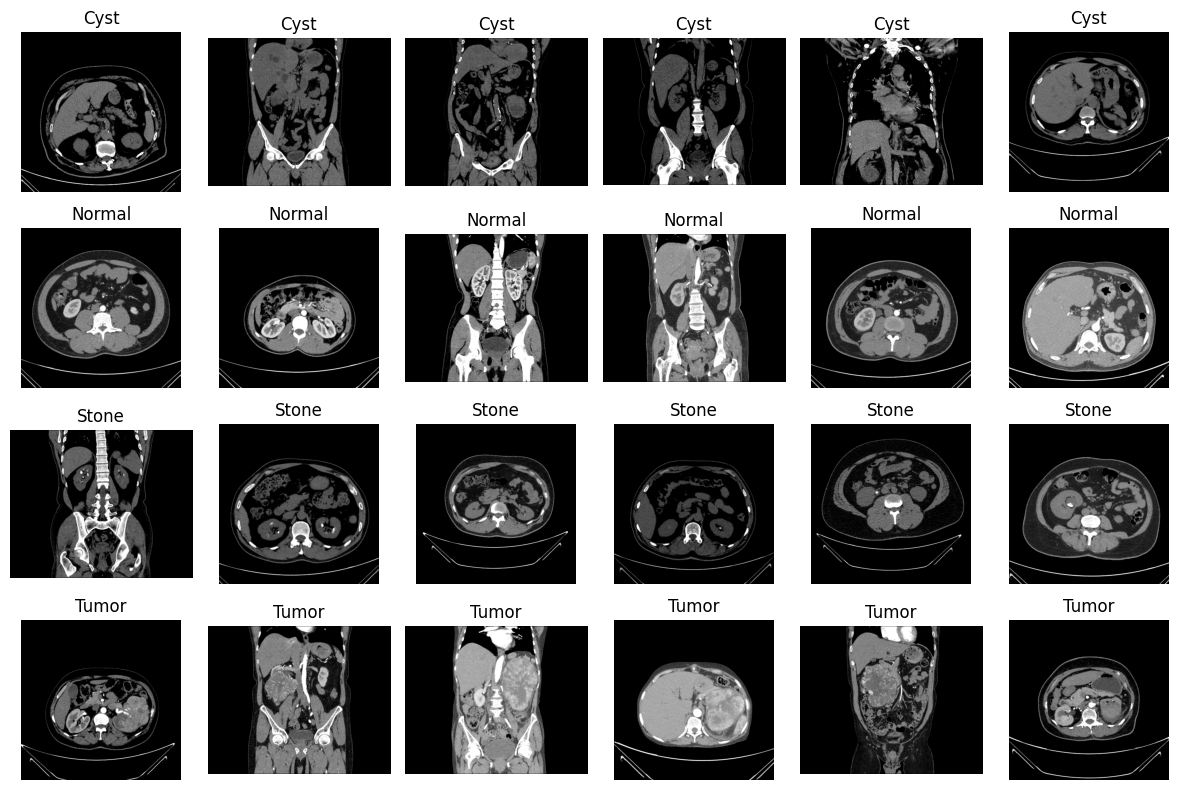

In [15]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# List of categories to display
classes_to_display = ['Cyst', 'Normal', 'Stone', 'Tumor']

# Set up the figure and axes (increase to 6 images per category)
fig, axes = plt.subplots(4, 6, figsize=(12, 8))  # Change columns to display 6 images
axes = axes.flatten()

# Display sample images
for i, label in enumerate(classes_to_display):
    class_data = df[df['label'] == label]
    sample_images = random.sample(list(class_data['file_path']), 6)

    for j, img_path in enumerate(sample_images):
        img = mpimg.imread(img_path)
        axes[i * 6 + j].imshow(img)  # Correctly set the axis
        axes[i * 6 + j].axis('off')  # Hide the axes
        axes[i * 6 + j].set_title(label)  # Add the category title

plt.tight_layout()
plt.show()


In [16]:
# Assign a numeric value to each category
label_mapping = {'Normal': 1, 'Cyst': 0, 'Stone': 2, 'Tumor': 3}

# Apply the mapping
df['numeric_label'] = df['label'].map(label_mapping)

# Display the DataFrame after modification
print(df[['label', 'numeric_label']])




        label  numeric_label
0        Cyst              0
1        Cyst              0
2        Cyst              0
3        Cyst              0
4        Cyst              0
...       ...            ...
12441  Normal              1
12442  Normal              1
12443  Normal              1
12444  Normal              1
12445  Normal              1

[12446 rows x 2 columns]


In [17]:
df.head()

,file_path,label,numeric_label
0,CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...,Cyst,0
1,CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...,Cyst,0
2,CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...,Cyst,0
3,CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...,Cyst,0
4,CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...,Cyst,0


In [18]:
import os
import pandas as pd
from pathlib import Path

train_dir = Path("CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone")

# Define paths for the four categories
normal_cases_dir = train_dir / 'Normal'
cyst_cases_dir = train_dir / 'Cyst'
stone_cases_dir = train_dir / 'Stone'
tumor_cases_dir = train_dir / 'Tumor'

# Retrieve the list of images for each category
normal_cases = list(normal_cases_dir.glob('*.jpg'))
cyst_cases = list(cyst_cases_dir.glob('*.jpg'))
stone_cases = list(stone_cases_dir.glob('*.jpg'))
tumor_cases = list(tumor_cases_dir.glob('*.jpg'))

# Create a list of images and their labels
train_data = []

for img in cyst_cases:
    train_data.append((str(img), 1))  # Class Cyst = 1
for img in normal_cases:
    train_data.append((str(img), 0))  # Class Normal = 0
for img in stone_cases:
    train_data.append((str(img), 3))  # Class Stone = 3
for img in tumor_cases:
    train_data.append((str(img), 2))  # Class Tumor = 2

# Convert the list into a DataFrame
train_data = pd.DataFrame(train_data, columns=['image', 'label'])

# Shuffle the data
train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify the data
print(train_data.head())


                                               image  label
0  CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...      1
1  CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...      1
2  CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...      3
3  CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...      1
4  CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-K...      1


# Oversampilng

 Befor Oversampling:
label
0    5077
1    3709
2    2283
3    1377
Name: count, dtype: int64


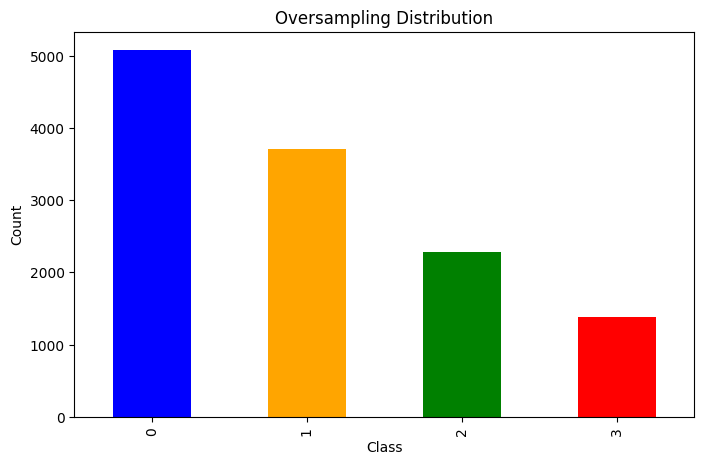

In [19]:
import matplotlib.pyplot as plt

# Calculate the number of samples in each category
class_counts = train_data['label'].value_counts()
print(" Befor Oversampling:")
print(class_counts)

# Plot the distribution
plt.figure(figsize=(8,5))
class_counts.plot(kind='bar', color=['blue', 'orange', 'green', 'red'])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Oversampling Distribution")
plt.show()


After Oversampling:
label
1    5077
0    5077
2    5077
3    5077
Name: count, dtype: int64


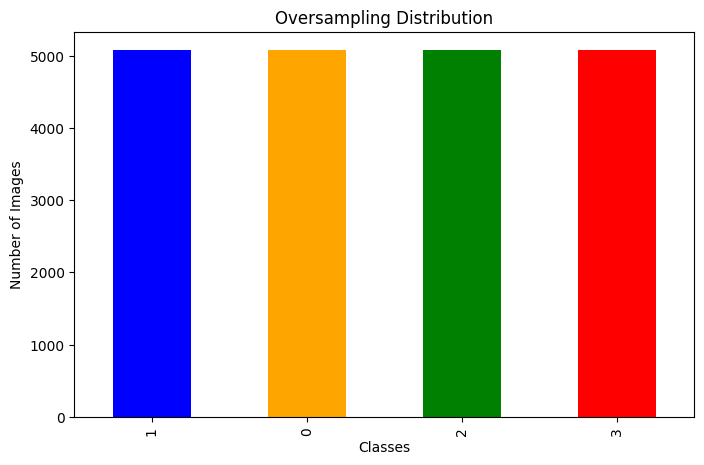

In [20]:
from sklearn.utils import resample
import matplotlib.pyplot as plt

# Calculate the maximum number of samples in any category
max_count = class_counts.max()

# List to store the balanced data
balanced_data = []

# Apply oversampling to each category
for label, count in class_counts.items():
    subset = train_data[train_data['label'] == label]
    if count < max_count:
        subset = resample(subset, replace=True, n_samples=max_count, random_state=42)
    balanced_data.append(subset)

# Combine all categories after balancing
train_data_balanced = pd.concat(balanced_data)

# Shuffle the data randomly
train_data_balanced = train_data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify the new distribution
print("After Oversampling:")
print(train_data_balanced['label'].value_counts())

# Plot the distribution after oversampling
plt.figure(figsize=(8,5))
train_data_balanced['label'].value_counts().plot(kind='bar', color=['blue', 'orange', 'green', 'red'])
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Oversampling Distribution")
plt.show()


In [21]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# Copy of the original training data
train_data_balanced = train_data.copy()

# Create a RandomOverSampler instance to balance the classes
oversampler = RandomOverSampler(random_state=42)

# Apply oversampling to the data
X_resampled, y_resampled = oversampler.fit_resample(train_data_balanced[['image']], train_data_balanced['label'])

# Convert the resampled data into a new DataFrame
train_data_balanced = pd.DataFrame({'image': X_resampled['image'], 'label': y_resampled})

# Print the class distribution after oversampling
print(train_data_balanced['label'].value_counts())



label
1    5077
3    5077
2    5077
0    5077
Name: count, dtype: int64


# Split the dataset into training (80%) and testing (20%) with stratified sampling

In [22]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) with stratified sampling
train_data, test_data = train_test_split(train_data, test_size=0.2, stratify=train_data['label'], random_state=42)

# Verify the distribution
print("Training Set Distribution:\n", train_data['label'].value_counts())
print("Test Set Distribution:\n", test_data['label'].value_counts())


Training Set Distribution:
 label
0    4061
1    2967
2    1826
3    1102
Name: count, dtype: int64
Test Set Distribution:
 label
0    1016
1     742
2     457
3     275
Name: count, dtype: int64


In [23]:

train_data['label'] = train_data['label'].astype(str)


In [24]:
test_data['label'] = test_data['label'].astype(str)


In [25]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# Create a copy of the original training data
train_data_balanced = train_data.copy()

# Initialize RandomOverSampler to balance class distribution
oversampler = RandomOverSampler(random_state=42)

# Apply oversampling to the dataset
X_resampled, y_resampled = oversampler.fit_resample(train_data_balanced[['image']], train_data_balanced['label'])

# Convert the resampled data into a DataFrame
train_data_balanced = pd.DataFrame({'image': X_resampled['image'], 'label': y_resampled})

# Print the class distribution after oversampling
print(train_data_balanced['label'].value_counts())



label
0    4061
1    4061
3    4061
2    4061
Name: count, dtype: int64


 # Data Augmentation

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize ImageDataGenerator for training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1/255,           # Normalize pixel values to [0, 1]
    rotation_range=10,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Initialize ImageDataGenerator for test data without augmentation
test_datagen = ImageDataGenerator(rescale=1/255)

# Apply augmentation to the training data
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data_balanced,
    x_col='image',          # Column name for image paths
    y_col='label',          # Column name for labels
    target_size=(224, 224),  # Resize images to 224x224
    batch_size=32,           # Use a batch size of 32
    class_mode='categorical', # Use categorical labels
    shuffle=True            # Shuffle data during training
)

# Prepare test data without augmentation
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_data,
    x_col='image',          # Column name for image paths
    y_col='label',          # Column name for labels
    target_size=(224, 224),  # Resize images to 224x224
    batch_size=32,           # Use a batch size of 32
    class_mode='categorical', # Use categorical labels
    shuffle=False           # Do not shuffle test data
)


Found 16244 validated image filenames belonging to 4 classes.
Found 2490 validated image filenames belonging to 4 classes.


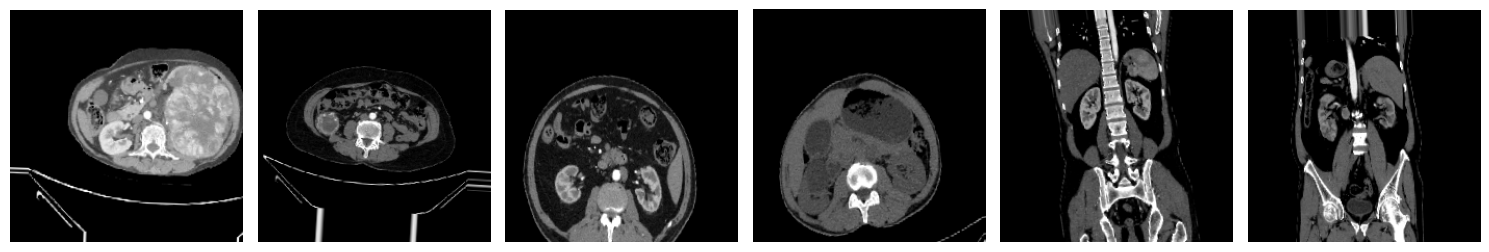

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Number of images to display
num_images = 6

# Retrieve a batch of images from the generator
augmented_images, _ = next(train_generator)

# Ensure we don't exceed the available images
num_images = min(num_images, augmented_images.shape[0])

# Create a figure and display the images
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

for i in range(num_images):
    img = augmented_images[i]
    img = np.clip(img, 0, 1)  # Ensure pixel values are in the [0, 1] range
    axes[i].imshow(img)
    axes[i].axis("off")

plt.tight_layout()
plt.show()




# CNN Model

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, BatchNormalization, GlobalMaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Build the model
model = Sequential()

# First layer: Convolutional + BatchNorm + MaxPooling
model.add(Conv2D(32, (3, 3), input_shape=(224, 224, 3)))
model.add(tf.keras.layers.LeakyReLU(alpha=0.01))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Second layer: Convolutional + BatchNorm + MaxPooling
model.add(Conv2D(64, (3, 3)))
model.add(tf.keras.layers.LeakyReLU(alpha=0.01))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Third layer: Convolutional + BatchNorm + MaxPooling
model.add(Conv2D(128, (3, 3)))
model.add(tf.keras.layers.LeakyReLU(alpha=0.01))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Fourth layer: Convolutional + BatchNorm + MaxPooling
model.add(Conv2D(256, (3, 3)))
model.add(tf.keras.layers.LeakyReLU(alpha=0.01))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Replace Flatten with GlobalMaxPooling2D
model.add(GlobalMaxPooling2D())

# Fully Connected layers
model.add(Dense(256))
model.add(tf.keras.layers.LeakyReLU(alpha=0.01))
model.add(Dense(128))
model.add(tf.keras.layers.LeakyReLU(alpha=0.01))

# Output layer: 4-class classification
model.add(Dense(4, activation='softmax'))

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Setup Callbacks
checkpoint = ModelCheckpoint('./kidneymodel.keras', save_best_only=True, monitor='val_loss', mode='min', verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 109, 109, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 489,540 (1.87 MB)

 Trainable params: 488,580 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [29]:
import tensorflow as tf

Epochs = 80

class UserPromptCallback(tf.keras.callbacks.Callback):
    def __init__(self, prompt_frequency, max_epochs=Epochs):
        super(UserPromptCallback, self).__init__()
        self.prompt_frequency = prompt_frequency
        self.max_epochs = max_epochs
        self.remaining_epochs = prompt_frequency

    def on_epoch_end(self, epoch, logs=None):
        # Stop if max_epochs is reached
        if epoch + 1 >= self.max_epochs:
            print(f"Reached maximum epoch {self.max_epochs}. Stopping training.")
            self.model.stop_training = True
            return

        # Ask user for input every 'prompt_frequency' epochs
        self.remaining_epochs -= 1
        if self.remaining_epochs <= 0:
            response = input(f"Epoch {epoch + 1} completed. Do you want to stop training or add more epochs? (stop/add): ").strip().lower()
            if response == 'stop':
                print("Stopping training as requested by the user.")
                self.model.stop_training = True
            elif response == 'add':
                try:
                    additional_epochs = int(input("How many more epochs to add? ").strip())
                    print(f"Added {additional_epochs} more epochs.")
                    self.max_epochs += additional_epochs  # Extend max_epochs
                    self.remaining_epochs = additional_epochs
                except ValueError:
                    print("Invalid input. Continuing training.")

# Create callback instance
user_prompt_callback = UserPromptCallback(prompt_frequency=20)
# Train model
history = model.fit(
    train_generator,
    epochs=Epochs,
    callbacks=[checkpoint,early_stopping,reduce_lr, user_prompt_callback],
    validation_data=test_generator
)
model.save('kidneymodel.keras')

# rest test_generator
test_generator.reset()

# Evaluate on test data
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc * 100:.2f}%')




Epoch 1/80
508/508 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.5244 - loss: 1.1907
Epoch 1: val_loss improved from inf to 1.07082, saving model to ./kidneymodel.keras
508/508 ━━━━━━━━━━━━━━━━━━━━ 265s 498ms/step - accuracy: 0.5246 - loss: 1.1901 - val_accuracy: 0.4406 - val_loss: 1.0708 - learning_rate: 1.0000e-04
Epoch 2/80
508/508 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.8231 - loss: 0.4572
Epoch 2: val_loss improved from 1.07082 to 0.48754, saving model to ./kidneymodel.keras
508/508 ━━━━━━━━━━━━━━━━━━━━ 237s 467ms/step - accuracy: 0.8231 - loss: 0.4571 - val_accuracy: 0.8297 - val_loss: 0.4875 - learning_rate: 1.0000e-04
Epoch 3/80
508/508 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9117 - loss: 0.2493
Epoch 3: val_loss did not improve from 0.48754
508/508 ━━━━━━━━━━━━━━━━━━━━ 237s 467ms/step - accuracy: 0.9117 - loss: 0.2493 - val_accuracy: 0.8398 - val_loss: 0.4929 - learning_rate: 1.0000e-04
Epoch 4/80
508/508 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.93

In [30]:
def plot_metrics(history):

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()


    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step


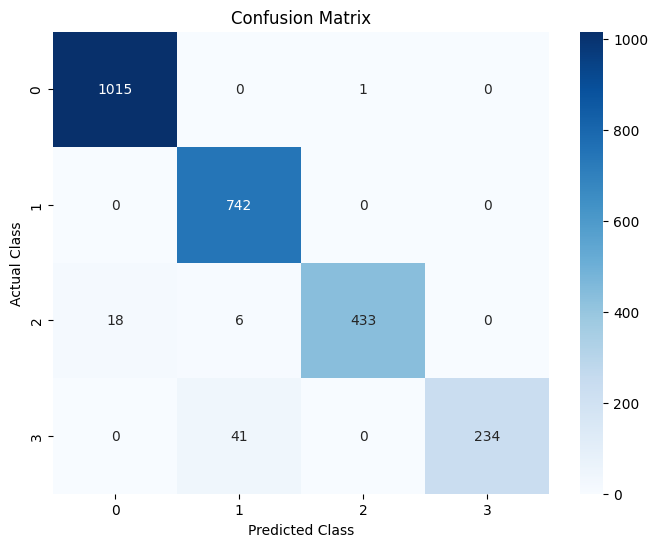

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1016
           1       0.94      1.00      0.97       742
           2       1.00      0.95      0.97       457
           3       1.00      0.85      0.92       275

    accuracy                           0.97      2490
   macro avg       0.98      0.95      0.96      2490
weighted avg       0.97      0.97      0.97      2490



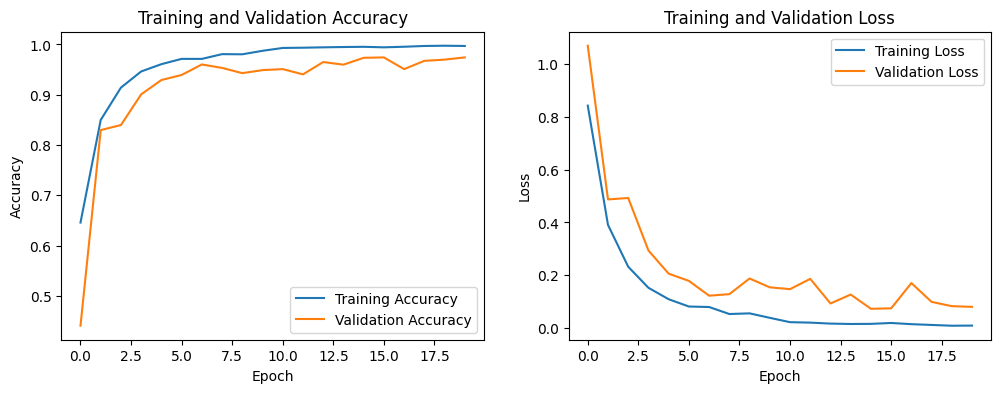

In [31]:
#  Predictions for confusion matrix and classification report
y_true = test_generator.classes  # True labels from the test generator
y_pred = np.argmax(model.predict(test_generator), axis=1)  # Predicted class indices

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

# Classification Report
class_report = classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys()))
print("Classification Report:\n", class_report)
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)
plot_metrics(history)


In [32]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc * 100:.2f}%')


78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.9744 - loss: 0.0634
Test accuracy: 97.35%


In [33]:

model.save('kidney_disease_model.h5')


🖼️ الصورة: CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (5000).jpg
✅ الفئة الفعلية: Normal
🔍 التوقع: Normal
⚡ نسبة الثقة: 100.00%


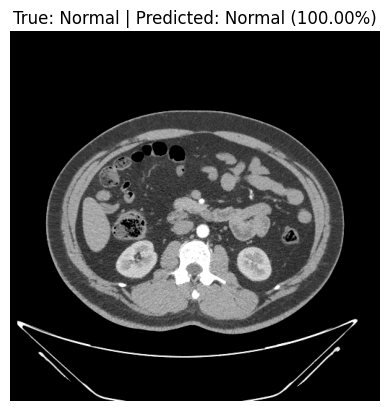

In [34]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model('./kidneymodel.keras')

class_names = ['Normal', 'Cyst', 'Tumor', 'Stone']

def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    if image is None:
        raise ValueError("❌ الصورة لم يتم تحميلها، راجع المسار")

    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    image = cv2.resize(image, (224, 224))
    image = image.astype(np.float32) / 255.0
    image = np.expand_dims(image, axis=0)

    return image

def predict_image(image_path):
    true_class = os.path.basename(os.path.dirname(image_path))
    processed_image = preprocess_image(image_path)

    prediction = model.predict(processed_image, verbose=0)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    print(f"🖼️ الصورة: {image_path}")
    print(f"✅ الفئة الفعلية: {true_class}")
    print(f"🔍 التوقع: {class_names[predicted_class]}")
    print(f"⚡ نسبة الثقة: {confidence * 100:.2f}%")

    img = cv2.imread(image_path)[:, :, ::-1]
    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"True: {true_class} | Predicted: {class_names[predicted_class]} "
        f"({confidence * 100:.2f}%)"
    )
    plt.show()

image_path = "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal/Normal- (5000).jpg"
predict_image(image_path)

In [35]:

import matplotlib.pyplot as plt
import numpy as np

# Plotting Training and Validation Metrics
def plot_training(hist):
    # Extracting accuracy and loss values
    tr_acc = hist.history['accuracy']
    tr_loss = hist.history['loss']
    val_acc = hist.history['val_accuracy']
    val_loss = hist.history['val_loss']

    # Finding the best epochs for loss and accuracy
    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]

    # Plot settings
    plt.figure(figsize=(20, 8))
    plt.style.use('fivethirtyeight')
    epochs = [i + 1 for i in range(len(tr_acc))]
    loss_label = f'Best Epoch = {index_loss + 1}'
    acc_label = f'Best Epoch = {index_acc + 1}'

    # Plotting Training and Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, tr_loss, 'r', label='Training Loss')
    plt.plot(epochs, val_loss, 'g', label='Validation Loss')
    plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plotting Training and Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, tr_acc, 'r', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'g', label='Validation Accuracy')
    plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()